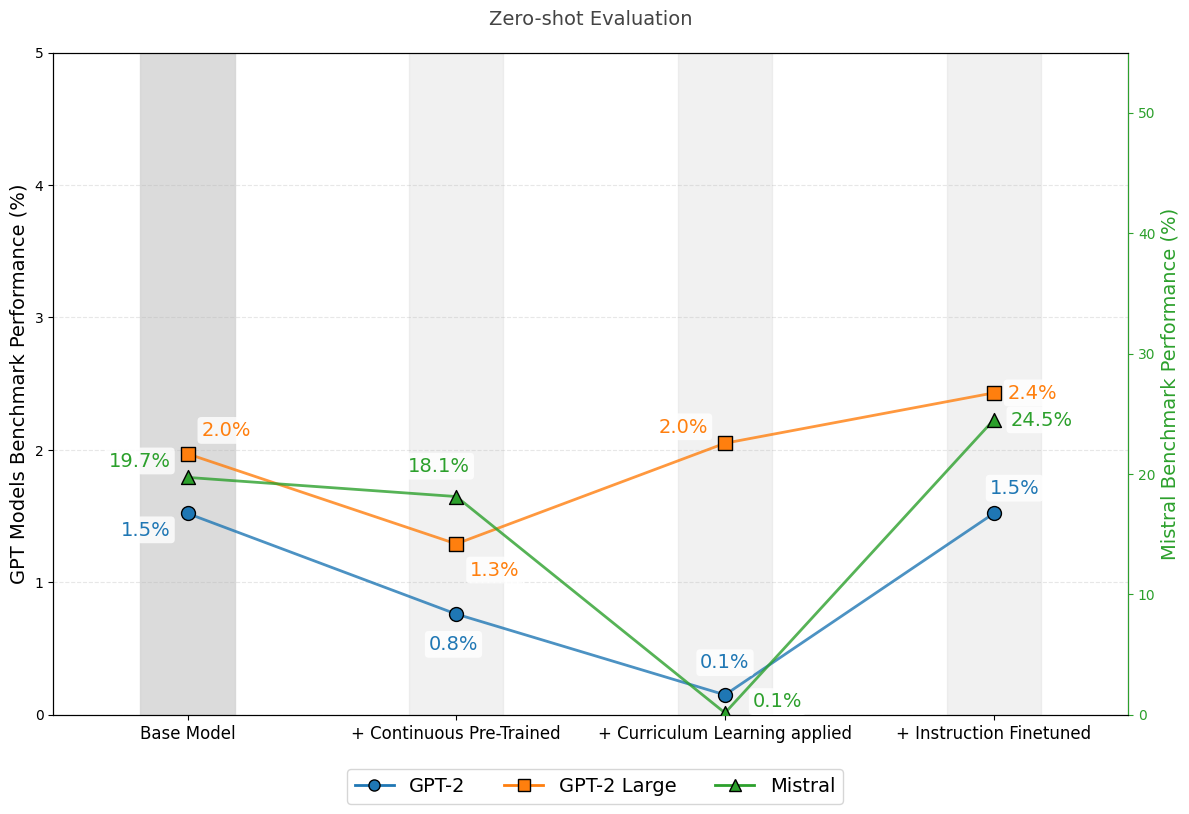

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Load the data from the Excel file
# Note: Update the path to your actual file location
df = pd.read_excel('/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/Performances.xlsx', engine='openpyxl')

# Ensure the columns are numeric
# Using the correct column name "Zero Shot"
df['Zero Shot'] = pd.to_numeric(df['Zero Shot'], errors='coerce')

# Extract unique models and training types
models = df['Model'].unique()
training_types = df['Training Type'].unique()

# Define training type positions on x-axis
training_positions = {training: i+1 for i, training in enumerate(training_types)}

# Define colors and markers for models with better visual distinction
model_colors = {
    'GPT-2': '#1f77b4',         # Blue
    'GPT-2 Large': '#ff7f0e',   # Orange
    'Mistral': '#2ca02c'        # Green
}

model_markers = {
    'GPT-2': 'o',         # Circle
    'GPT-2 Large': 's',   # Square
    'Mistral': '^'        # Triangle
}

# Create a figure with a single plot area - slightly taller for legend space at bottom
fig, ax_left = plt.subplots(figsize=(12, 9))

# Create a right y-axis for Mistral
ax_right = ax_left.twinx()

# Set colors for axes
left_color = 'black'      # GPT models
right_color = '#2ca02c'   # Mistral - green

# Style the y-axes
ax_left.tick_params(axis='y', colors=left_color)
ax_left.spines['left'].set_color(left_color)
ax_right.tick_params(axis='y', colors=right_color)
ax_right.spines['right'].set_color(right_color)

# Create wider training "bars" instead of lines
bar_width = 0.35  # Width for bars
for training, x_pos in training_positions.items():
    # Draw wider "bars" for each training position
    # Make the "Raw" section significantly darker
    if training == 'Raw':
        alpha_value = 0.8  # Darker alpha for Base Model (Raw)
    else:
        alpha_value = 0.3  # Keep original alpha for others
        
    ax_left.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 5, 
                              color='lightgray', alpha=alpha_value, zorder=0))

# Prepare data for connecting lines between training types for the same model
model_data = {model: {'x': [], 'y': [], 'training': []} for model in models}

# First, collect all data points
for training, x_pos in training_positions.items():
    # For each model
    for model in models:
        # Get data for this model and training combination
        data_row = df[(df['Model'] == model) & (df['Training Type'] == training)]
        
        if not data_row.empty:
            # Get Zero-shot value with correct column name
            zero_shot = data_row['Zero Shot'].iloc[0]
            
            # Store x and y for connecting lines later
            model_data[model]['x'].append(x_pos)
            model_data[model]['y'].append(zero_shot)
            model_data[model]['training'].append(training)

# Plot data and connect lines for each model
for model, data in model_data.items():
    x_values = data['x']
    y_values = data['y']
    
    # Choose appropriate axis based on model type
    if model == 'Mistral':
        ax = ax_right
    else:
        ax = ax_left
    
    # Draw connecting lines first (beneath points)
    ax.plot(x_values, y_values, color=model_colors[model], linestyle='-', 
            linewidth=2, alpha=0.8, zorder=2)
    
    # Draw points
    ax.scatter(x_values, y_values, 
              color=model_colors[model], marker=model_markers[model], 
              s=100, zorder=3, edgecolors='black', linewidth=1)
    
    # Add small labels for each data point with white background for better readability
    # Use predefined positions to avoid overlaps
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        training = data['training'][i]
        
        # Custom positioning for each data point based on model and training type
        # to avoid overlaps without using external libraries
        if model == 'Mistral':
            if training == 'Raw':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 10, 15 
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 20, 15  # RIGHT of data point, slightly lower
                ha, va = 'left', 'top'
            else:  # Instruction Finetuned
                offset_x, offset_y = 12, 0  # Just right of data point
                ha, va = 'left', 'center'
        elif model == 'GPT-2':
            if training == 'Raw':
                offset_x, offset_y = -12, -5
                ha, va = 'right', 'top'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -2, -15
                ha, va = 'center', 'top'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 0, 30  # ABOVE data point with MORE distance
                ha, va = 'center', 'top'
            else:  # Instruction Finetuned
                offset_x, offset_y = 15, 25  # Just above data point
                ha, va = 'center', 'top'
        else:  # GPT-2 Large
            if training == 'Raw':
                offset_x, offset_y = 10, 10
                ha, va = 'left', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 10, -12
                ha, va = 'left', 'top'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = -12, 5  # LEFT and ABOVE data point
                ha, va = 'right', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 10, 0  # RIGHT of data point
                ha, va = 'left', 'center'
        
        # Create label with white background for better readability
        ax.annotate(
            f"{y:.1f}%", 
            xy=(x, y),
            xytext=(offset_x, offset_y),
            textcoords='offset points',
            ha=ha, va=va,
            fontsize=14,
            color=model_colors[model],
            bbox=dict(boxstyle="round,pad=0.2", fc='white', ec="none", alpha=0.8)
        )

# Set y-axis limits with some padding
ax_left.set_ylim(0, 5)      # GPT models scale (0-5%)
ax_right.set_ylim(0, 55)    # Mistral scale (0-55%)

# Modify x-axis labels: Add "+" in front except for "Raw" and change "Curriculum Learning" to "Curriculum Learning applied"
modified_labels = []
for label in training_positions.keys():
    if label == 'Raw':
        modified_labels.append("Base Model")  # Changed from "Raw" to "Base Model"
    elif label == 'Curriculum Learning':
        modified_labels.append("+ Curriculum Learning applied")
    else:
        modified_labels.append("+ " + label)

# Set x-axis labels
ax_left.set_xticks(list(training_positions.values()))
ax_left.set_xticklabels(modified_labels, fontsize=12, rotation=0, ha='center')
ax_left.set_xlim(0.5, len(training_types) + 0.5)  # Set x-axis limits with padding

# Set y-axis labels
ax_left.set_ylabel('GPT Models Benchmark Performance (%)', fontsize=14, color=left_color)
ax_right.set_ylabel('Mistral Benchmark Performance (%)', fontsize=14, color=right_color)

# Create custom legend with both line and marker
model_legend = []
for model in models:
    model_legend.append(Line2D([0], [0], marker=model_markers[model], color=model_colors[model], 
                      label=model, markersize=8, linestyle='-', linewidth=2,
                      markerfacecolor=model_colors[model], markeredgecolor='black'))

# Add the legend at the bottom of the plot
fig.legend(handles=model_legend, 
          loc='upper center', bbox_to_anchor=(0.5, 0.15),
          ncol=len(models), fontsize=14)

# Add subtitle as the second line in the suptitle with proper spacing
plt.title('Zero-shot Evaluation', 
          fontsize=14,  # Smaller than the main title
          color='#444444',  # Dark grey
          pad=20)  # Add padding to move it down from the main title

# Add grid lines for readability
ax_left.grid(axis='y', linestyle='--', alpha=0.3)

# Adjust layout - make more room at the bottom for the legend and for the x-axis label
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Increased from 0.15 to 0.2 for the x-axis label

# Save the plot
plt.savefig('zero_shot_benchmark_performance.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

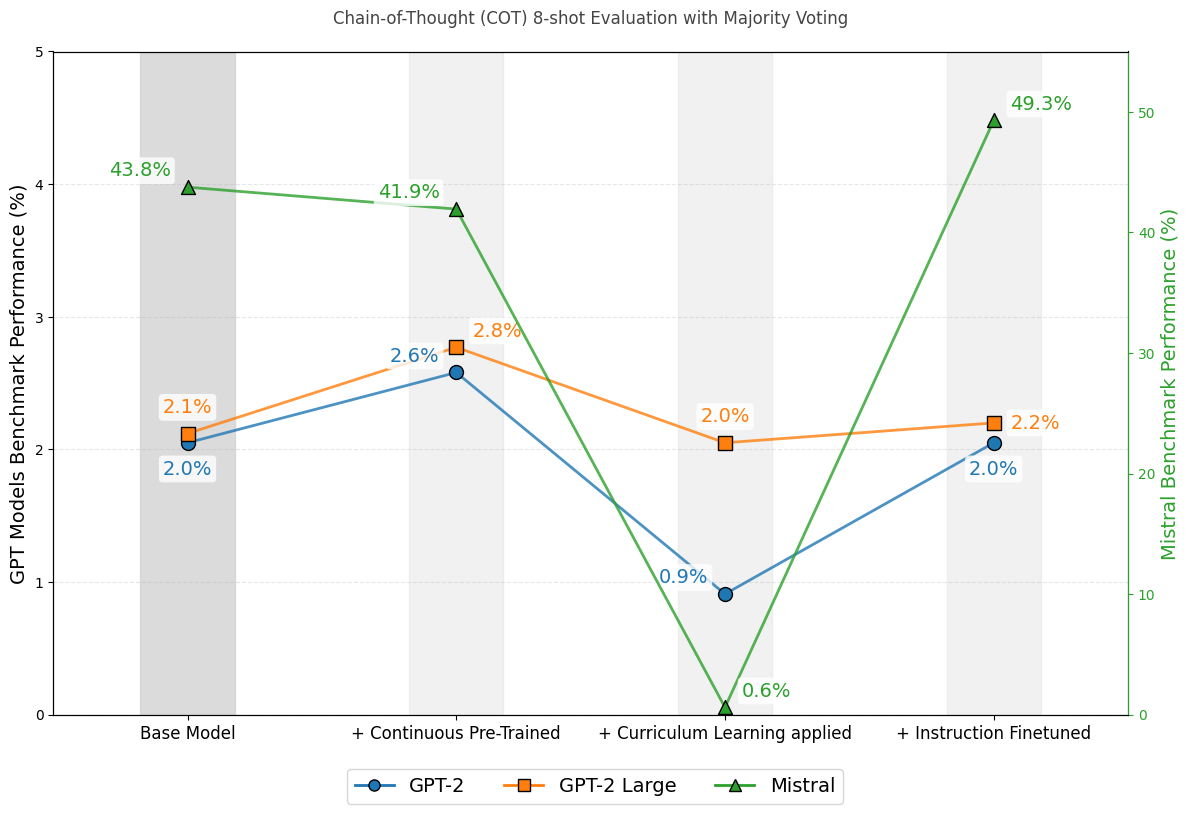

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Load the data from the Excel file
# Note: Update the path to your actual file location
df = pd.read_excel('/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/Performances.xlsx', engine='openpyxl')

# Ensure the columns are numeric
df['COT 8-shot maj1@8'] = pd.to_numeric(df['COT 8-shot maj1@8'], errors='coerce')

# Extract unique models and training types
models = df['Model'].unique()
training_types = df['Training Type'].unique()

# Define training type positions on x-axis
training_positions = {training: i+1 for i, training in enumerate(training_types)}

# Define colors and markers for models with better visual distinction
model_colors = {
    'GPT-2': '#1f77b4',         # Blue
    'GPT-2 Large': '#ff7f0e',   # Orange
    'Mistral': '#2ca02c'        # Green
}

model_markers = {
    'GPT-2': 'o',         # Circle
    'GPT-2 Large': 's',   # Square
    'Mistral': '^'        # Triangle
}

# Create a figure with a single plot area - slightly taller for legend space at bottom
fig, ax_left = plt.subplots(figsize=(12, 9))

# Create a right y-axis for Mistral
ax_right = ax_left.twinx()

# Set colors for axes
left_color = 'black'      # GPT models
right_color = '#2ca02c'   # Mistral - green

# Style the y-axes
ax_left.tick_params(axis='y', colors=left_color)
ax_left.spines['left'].set_color(left_color)
ax_right.tick_params(axis='y', colors=right_color)
ax_right.spines['right'].set_color(right_color)

# Create wider training "bars" instead of lines
bar_width = 0.35  # Width for bars
for training, x_pos in training_positions.items():
    # Draw wider "bars" for each training position
    # Make the "Raw" section significantly darker
    if training == 'Raw':
        alpha_value = 0.8  # Darker alpha for Base Model (Raw)
    else:
        alpha_value = 0.3  # Keep original alpha for others
        
    ax_left.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 5, 
                              color='lightgray', alpha=alpha_value, zorder=0))

# Prepare data for connecting lines between training types for the same model
model_data = {model: {'x': [], 'y': [], 'training': []} for model in models}

# First, collect all data points
for training, x_pos in training_positions.items():
    # For each model
    for model in models:
        # Get data for this model and training combination
        data_row = df[(df['Model'] == model) & (df['Training Type'] == training)]
        
        if not data_row.empty:
            # Get COT value
            cot = data_row['COT 8-shot maj1@8'].iloc[0]
            
            # Store x and y for connecting lines later
            model_data[model]['x'].append(x_pos)
            model_data[model]['y'].append(cot)
            model_data[model]['training'].append(training)

# Plot data and connect lines for each model
for model, data in model_data.items():
    x_values = data['x']
    y_values = data['y']
    
    # Choose appropriate axis based on model type
    if model == 'Mistral':
        ax = ax_right
    else:
        ax = ax_left
    
    # Draw connecting lines first (beneath points)
    ax.plot(x_values, y_values, color=model_colors[model], linestyle='-', 
            linewidth=2, alpha=0.8, zorder=2)
    
    # Draw points
    ax.scatter(x_values, y_values, 
              color=model_colors[model], marker=model_markers[model], 
              s=100, zorder=3, edgecolors='black', linewidth=1)
    
    # Add small labels for each data point with white background for better readability
    # Use predefined positions to avoid overlaps
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        training = data['training'][i]
        
        # Custom positioning for each data point based on model and training type
        # to avoid overlaps without using external libraries
        if model == 'Mistral':
            if training == 'Raw':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -12, 5 
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
        elif model == 'GPT-2':
            if training == 'Raw':
                offset_x, offset_y = 0, -12
                ha, va = 'center', 'top'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 0, -12
                ha, va = 'center', 'top'
        else:  # GPT-2 Large
            if training == 'Raw':
                offset_x, offset_y = 0, 12
                ha, va = 'center', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 0, 12
                ha, va = 'center', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 12, 0
                ha, va = 'left', 'center'
        
        # Create label with white background for better readability
        ax.annotate(
            f"{y:.1f}%", 
            xy=(x, y),
            xytext=(offset_x, offset_y),
            textcoords='offset points',
            ha=ha, va=va,
            fontsize=14,
            color=model_colors[model],
            bbox=dict(boxstyle="round,pad=0.2", fc='white', ec="none", alpha=0.8)
        )

# Set y-axis limits with some padding
ax_left.set_ylim(0, 5)      # GPT models scale (0-5%)
ax_right.set_ylim(0, 55)    # Mistral scale (0-55%)

# Modify x-axis labels: Add "+" in front except for "Raw" and change "Curriculum Learning" to "Curriculum Learning applied"
modified_labels = []
for label in training_positions.keys():
    if label == 'Raw':
        modified_labels.append("Base Model")  # Changed from "Raw" to "Base Model"
    elif label == 'Curriculum Learning':
        modified_labels.append("+ Curriculum Learning applied")
    else:
        modified_labels.append("+ " + label)

# Set x-axis labels
ax_left.set_xticks(list(training_positions.values()))
ax_left.set_xticklabels(modified_labels, fontsize=12, rotation=0, ha='center')
ax_left.set_xlim(0.5, len(training_types) + 0.5)  # Set x-axis limits with padding


# Set y-axis labels
ax_left.set_ylabel('GPT Models Benchmark Performance (%)', fontsize=14, color=left_color)
ax_right.set_ylabel('Mistral Benchmark Performance (%)', fontsize=14, color=right_color)

# Create custom legend with both line and marker
model_legend = []
for model in models:
    model_legend.append(Line2D([0], [0], marker=model_markers[model], color=model_colors[model], 
                      label=model, markersize=8, linestyle='-', linewidth=2,
                      markerfacecolor=model_colors[model], markeredgecolor='black'))

# Add the legend at the bottom of the plot
fig.legend(handles=model_legend, 
          loc='upper center', bbox_to_anchor=(0.5, 0.15),
          ncol=len(models), fontsize=14)


# Add subtitle as the second line in the suptitle with proper spacing
plt.title('Chain-of-Thought (COT) 8-shot Evaluation with Majority Voting', 
          fontsize=12,  # Smaller than the main title
          color='#444444',  # Dark grey
          pad=20)  # Add padding to move it down from the main title

# Add grid lines for readability
ax_left.grid(axis='y', linestyle='--', alpha=0.3)

# Adjust layout - make more room at the bottom for the legend and for the x-axis label
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Increased from 0.15 to 0.2 for the x-axis label

# Save the plot
plt.savefig('benchmark_performance_final.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

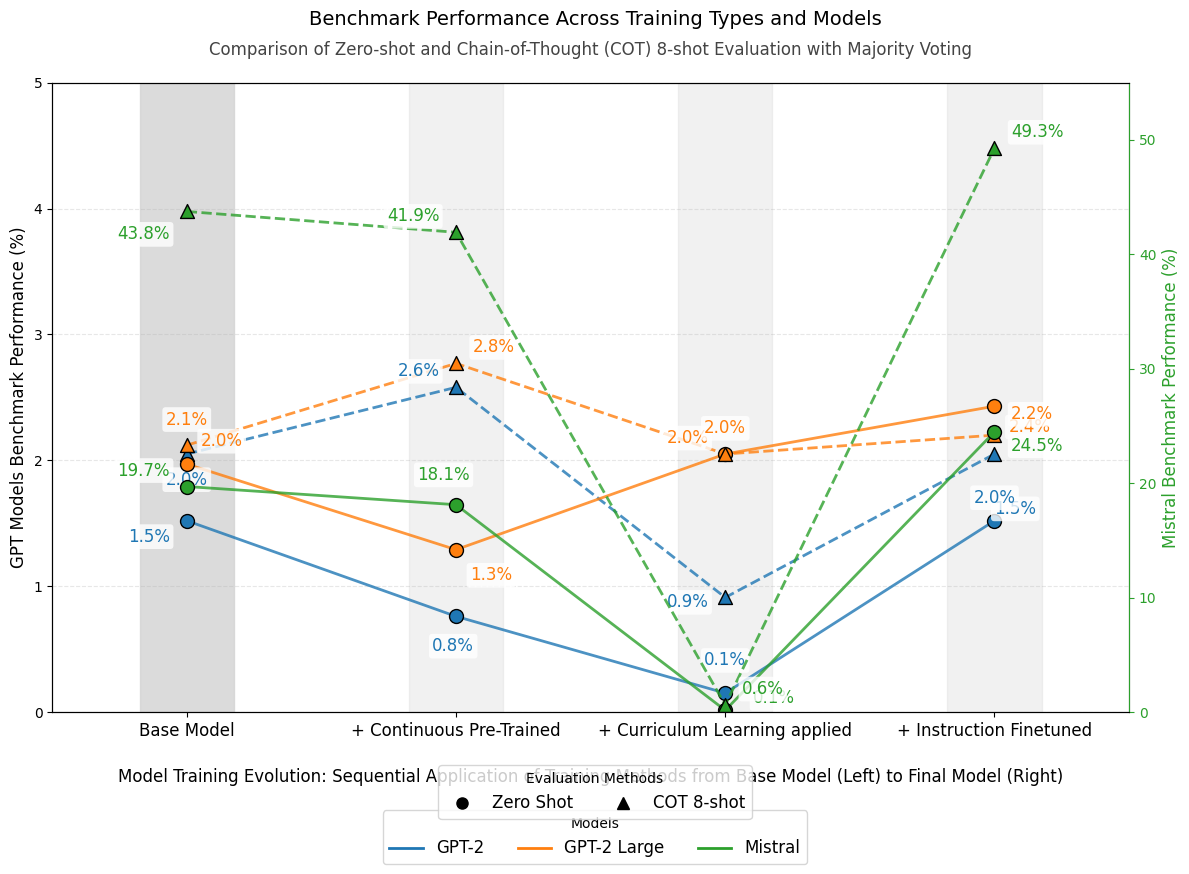

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Load the data from the Excel file
# Note: Update the path to your actual file location
df = pd.read_excel('/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/Performances.xlsx', engine='openpyxl')

# Ensure the columns are numeric
df['Zero Shot'] = pd.to_numeric(df['Zero Shot'], errors='coerce')
df['COT 8-shot maj1@8'] = pd.to_numeric(df['COT 8-shot maj1@8'], errors='coerce')

# Extract unique models and training types
models = df['Model'].unique()
training_types = df['Training Type'].unique()

# Define training type positions on x-axis
training_positions = {training: i+1 for i, training in enumerate(training_types)}

# Define colors for models with better visual distinction
model_colors = {
    'GPT-2': '#1f77b4',         # Blue
    'GPT-2 Large': '#ff7f0e',   # Orange
    'Mistral': '#2ca02c'        # Green
}

# Define markers for different evaluation methods
eval_markers = {
    'Zero Shot': 'o',     # Circle
    'COT 8-shot': '^'     # Triangle
}

# Create a figure with a single plot area - slightly taller for legend space at bottom
fig, ax_left = plt.subplots(figsize=(12, 9))

# Create a right y-axis for Mistral
ax_right = ax_left.twinx()

# Set colors for axes
left_color = 'black'      # GPT models
right_color = '#2ca02c'   # Mistral - green

# Style the y-axes
ax_left.tick_params(axis='y', colors=left_color)
ax_left.spines['left'].set_color(left_color)
ax_right.tick_params(axis='y', colors=right_color)
ax_right.spines['right'].set_color(right_color)

# Create wider training "bars" instead of lines
bar_width = 0.35  # Width for bars
for training, x_pos in training_positions.items():
    # Draw wider "bars" for each training position
    # Make the "Raw" section significantly darker
    if training == 'Raw':
        alpha_value = 0.8  # Darker alpha for Base Model (Raw)
    else:
        alpha_value = 0.3  # Keep original alpha for others
        
    ax_left.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 5, 
                              color='lightgray', alpha=alpha_value, zorder=0))

# Prepare data for connecting lines between training types for the same model and evaluation type
model_eval_data = {}
for model in models:
    model_eval_data[model] = {
        'Zero Shot': {'x': [], 'y': [], 'training': []},
        'COT 8-shot': {'x': [], 'y': [], 'training': []}
    }

# First, collect all data points
for training, x_pos in training_positions.items():
    # For each model
    for model in models:
        # Get data for this model and training combination
        data_row = df[(df['Model'] == model) & (df['Training Type'] == training)]
        
        if not data_row.empty:
            # Get Zero-shot value
            zero_shot = data_row['Zero Shot'].iloc[0]
            
            # Store x and y for connecting lines later
            model_eval_data[model]['Zero Shot']['x'].append(x_pos)
            model_eval_data[model]['Zero Shot']['y'].append(zero_shot)
            model_eval_data[model]['Zero Shot']['training'].append(training)
            
            # Get COT 8-shot value
            cot = data_row['COT 8-shot maj1@8'].iloc[0]
            
            # Store x and y for connecting lines later
            model_eval_data[model]['COT 8-shot']['x'].append(x_pos)
            model_eval_data[model]['COT 8-shot']['y'].append(cot)
            model_eval_data[model]['COT 8-shot']['training'].append(training)

# Plot data and connect lines for each model and evaluation type
for model in models:
    for eval_type, data in model_eval_data[model].items():
        x_values = data['x']
        y_values = data['y']
        
        # Choose appropriate axis based on model type
        if model == 'Mistral':
            ax = ax_right
        else:
            ax = ax_left
        
        # Draw connecting lines first (beneath points)
        ax.plot(x_values, y_values, color=model_colors[model], linestyle='-' if eval_type == 'Zero Shot' else '--', 
                linewidth=2, alpha=0.8, zorder=2)
        
        # Draw points
        ax.scatter(x_values, y_values, 
                  color=model_colors[model], marker=eval_markers[eval_type], 
                  s=100, zorder=3, edgecolors='black', linewidth=1)
        
        # Add small labels for each data point with white background for better readability
        # Use predefined positions to avoid overlaps
        for i, (x, y) in enumerate(zip(x_values, y_values)):
            training = data['training'][i]
            
            # Custom positioning for each data point based on model, training type, and evaluation method
            # This requires careful adjustment to avoid overlaps
            if model == 'Mistral':
                if eval_type == 'Zero Shot':
                    if training == 'Raw':
                        offset_x, offset_y = -12, 5
                        ha, va = 'right', 'bottom'
                    elif training == 'Continuous Pre-Trained':
                        offset_x, offset_y = 10, 15
                        ha, va = 'right', 'bottom'
                    elif training == 'Curriculum Learning':
                        offset_x, offset_y = 20, 15
                        ha, va = 'left', 'top'
                    else:  # Instruction Finetuned
                        offset_x, offset_y = 12, -10
                        ha, va = 'left', 'center'
                else:  # COT 8-shot
                    if training == 'Raw':
                        offset_x, offset_y = -12, -10
                        ha, va = 'right', 'top'
                    elif training == 'Continuous Pre-Trained':
                        offset_x, offset_y = -12, 5
                        ha, va = 'right', 'bottom'
                    elif training == 'Curriculum Learning':
                        offset_x, offset_y = 12, 5
                        ha, va = 'left', 'bottom'
                    else:  # Instruction Finetuned
                        offset_x, offset_y = 12, 5
                        ha, va = 'left', 'bottom'
            elif model == 'GPT-2':
                if eval_type == 'Zero Shot':
                    if training == 'Raw':
                        offset_x, offset_y = -12, -5
                        ha, va = 'right', 'top'
                    elif training == 'Continuous Pre-Trained':
                        offset_x, offset_y = -2, -15
                        ha, va = 'center', 'top'
                    elif training == 'Curriculum Learning':
                        offset_x, offset_y = 0, 30
                        ha, va = 'center', 'top'
                    else:  # Instruction Finetuned
                        offset_x, offset_y = 15, 15
                        ha, va = 'center', 'top'
                else:  # COT 8-shot
                    if training == 'Raw':
                        offset_x, offset_y = 0, -12
                        ha, va = 'center', 'top'
                    elif training == 'Continuous Pre-Trained':
                        offset_x, offset_y = -12, 5
                        ha, va = 'right', 'bottom'
                    elif training == 'Curriculum Learning':
                        offset_x, offset_y = -12, -10
                        ha, va = 'right', 'bottom'
                    else:  # Instruction Finetuned
                        offset_x, offset_y = 0, -25
                        ha, va = 'center', 'top'
            else:  # GPT-2 Large
                if eval_type == 'Zero Shot':
                    if training == 'Raw':
                        offset_x, offset_y = 10, 10
                        ha, va = 'left', 'bottom'
                    elif training == 'Continuous Pre-Trained':
                        offset_x, offset_y = 10, -12
                        ha, va = 'left', 'top'
                    elif training == 'Curriculum Learning':
                        offset_x, offset_y = -12, 5
                        ha, va = 'right', 'bottom'
                    else:  # Instruction Finetuned
                        offset_x, offset_y = 10, -15
                        ha, va = 'left', 'center'
                else:  # COT 8-shot
                    if training == 'Raw':
                        offset_x, offset_y = 0, 12
                        ha, va = 'center', 'bottom'
                    elif training == 'Continuous Pre-Trained':
                        offset_x, offset_y = 12, 5
                        ha, va = 'left', 'bottom'
                    elif training == 'Curriculum Learning':
                        offset_x, offset_y = 0, 12
                        ha, va = 'center', 'bottom'
                    else:  # Instruction Finetuned
                        offset_x, offset_y = 12, 15
                        ha, va = 'left', 'center'
            
            # Create label with white background for better readability
            ax.annotate(
                f"{y:.1f}%", 
                xy=(x, y),
                xytext=(offset_x, offset_y),
                textcoords='offset points',
                ha=ha, va=va,
                fontsize=12,  # Set font size to 12 as requested
                color=model_colors[model],
                bbox=dict(boxstyle="round,pad=0.2", fc='white', ec="none", alpha=0.8)
            )

# Set y-axis limits with some padding
ax_left.set_ylim(0, 5)      # GPT models scale (0-5%)
ax_right.set_ylim(0, 55)    # Mistral scale (0-55%)

# Modify x-axis labels: Add "+" in front except for "Raw" and change "Curriculum Learning" to "Curriculum Learning applied"
modified_labels = []
for label in training_positions.keys():
    if label == 'Raw':
        modified_labels.append("Base Model")  # Changed from "Raw" to "Base Model"
    elif label == 'Curriculum Learning':
        modified_labels.append("+ Curriculum Learning applied")
    else:
        modified_labels.append("+ " + label)

# Set x-axis labels
ax_left.set_xticks(list(training_positions.values()))
ax_left.set_xticklabels(modified_labels, fontsize=12, rotation=0, ha='center')
ax_left.set_xlim(0.5, len(training_types) + 0.5)  # Set x-axis limits with padding

# Add x-axis label
ax_left.set_xlabel("Model Training Evolution: Sequential Application of Training Methods from Base Model (Left) to Final Model (Right)", 
                  fontsize=12, labelpad=20)

# Set y-axis labels
ax_left.set_ylabel('GPT Models Benchmark Performance (%)', fontsize=12, color=left_color)
ax_right.set_ylabel('Mistral Benchmark Performance (%)', fontsize=12, color=right_color)

# Create custom legend for both models and evaluation types
model_legend = []
for model in models:
    model_legend.append(Line2D([0], [0], color=model_colors[model], 
                      label=model, linewidth=2))

eval_legend = []
for eval_type, marker in eval_markers.items():
    eval_legend.append(Line2D([0], [0], marker=marker, color='black', 
                      label=eval_type, markersize=8, linestyle='None'))

# Add the legends at the bottom of the plot
fig.legend(handles=model_legend, 
          loc='upper center', bbox_to_anchor=(0.5, 0.1),
          ncol=len(models), fontsize=12, title="Models")

fig.legend(handles=eval_legend, 
          loc='upper center', bbox_to_anchor=(0.5, 0.15),
          ncol=len(eval_markers), fontsize=12, title="Evaluation Methods")

# Add title with subtitle as a multi-line title
plt.suptitle('Benchmark Performance Across Training Types and Models', 
             fontsize=14, y=0.98)

# Add subtitle as the second line in the suptitle with proper spacing
plt.title('Comparison of Zero-shot and Chain-of-Thought (COT) 8-shot Evaluation with Majority Voting', 
          fontsize=12,  # Smaller than the main title
          color='#444444',  # Dark grey
          pad=20)  # Add padding to move it down from the main title

# Add grid lines for readability
ax_left.grid(axis='y', linestyle='--', alpha=0.3)

# Adjust layout - make more room at the bottom for the legends and for the x-axis label
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Increased to make room for two legend rows

# Save the plot
plt.savefig('merged_benchmark_performance.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Load the data from the Excel file
# Note: Update the path to your actual file location
df = pd.read_excel('/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/Performances.xlsx', engine='openpyxl')

# Ensure the columns are numeric
df['Zero Shot'] = pd.to_numeric(df['Zero Shot'], errors='coerce')
df['COT 8-shot maj1@8'] = pd.to_numeric(df['COT 8-shot maj1@8'], errors='coerce')

# Extract unique models and training types
models = df['Model'].unique()
training_types = df['Training Type'].unique()

# Define training type positions on x-axis
training_positions = {training: i+1 for i, training in enumerate(training_types)}

# Define colors for models with better visual distinction
model_colors = {
    'GPT-2': '#1f77b4',         # Blue
    'GPT-2 Large': '#ff7f0e',   # Orange
    'Mistral': '#2ca02c'        # Green
}

model_markers = {
    'GPT-2': 'o',         # Circle
    'GPT-2 Large': 's',   # Square
    'Mistral': '^'        # Triangle
}

# Create a figure with two subplots side by side
fig, (ax_left_zero, ax_left_cot) = plt.subplots(1, 2, figsize=(20, 8))

# Create right y-axes for Mistral
ax_right_zero = ax_left_zero.twinx()
ax_right_cot = ax_left_cot.twinx()

# Set colors for axes
left_color = 'black'      # GPT models
right_color = '#2ca02c'   # Mistral - green

# Style the y-axes for zero-shot plot
ax_left_zero.tick_params(axis='y', colors=left_color)
ax_left_zero.spines['left'].set_color(left_color)
ax_right_zero.tick_params(axis='y', colors=right_color)
ax_right_zero.spines['right'].set_color(right_color)

# Style the y-axes for COT plot
ax_left_cot.tick_params(axis='y', colors=left_color)
ax_left_cot.spines['left'].set_color(left_color)
ax_right_cot.tick_params(axis='y', colors=right_color)
ax_right_cot.spines['right'].set_color(right_color)

# Create wider training "bars" for zero-shot plot
bar_width = 0.35  # Width for bars
for training, x_pos in training_positions.items():
    # Draw wider "bars" for each training position
    # Make the "Raw" section significantly darker
    if training == 'Raw':
        alpha_value = 0.8  # Darker alpha for Base Model (Raw)
    else:
        alpha_value = 0.3  # Keep original alpha for others
        
    ax_left_zero.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 5, 
                              color='lightgray', alpha=alpha_value, zorder=0))
    
    # Same for COT plot
    ax_left_cot.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 5, 
                              color='lightgray', alpha=alpha_value, zorder=0))

# Prepare data for connecting lines between training types for each model
model_data_zero = {model: {'x': [], 'y': [], 'training': []} for model in models}
model_data_cot = {model: {'x': [], 'y': [], 'training': []} for model in models}

# First, collect all data points
for training, x_pos in training_positions.items():
    # For each model
    for model in models:
        # Get data for this model and training combination
        data_row = df[(df['Model'] == model) & (df['Training Type'] == training)]
        
        if not data_row.empty:
            # Get Zero-shot value
            zero_shot = data_row['Zero Shot'].iloc[0]
            
            # Store x and y for connecting lines later for Zero-shot
            model_data_zero[model]['x'].append(x_pos)
            model_data_zero[model]['y'].append(zero_shot)
            model_data_zero[model]['training'].append(training)
            
            # Get COT 8-shot value
            cot = data_row['COT 8-shot maj1@8'].iloc[0]
            
            # Store x and y for connecting lines later for COT
            model_data_cot[model]['x'].append(x_pos)
            model_data_cot[model]['y'].append(cot)
            model_data_cot[model]['training'].append(training)

# Plot Zero-shot data
for model, data in model_data_zero.items():
    x_values = data['x']
    y_values = data['y']
    
    # Choose appropriate axis based on model type
    if model == 'Mistral':
        ax = ax_right_zero
    else:
        ax = ax_left_zero
    
    # Draw connecting lines first (beneath points)
    ax.plot(x_values, y_values, color=model_colors[model], linestyle='-', 
            linewidth=2, alpha=0.8, zorder=2)
    
    # Draw points
    ax.scatter(x_values, y_values, 
              color=model_colors[model], marker=model_markers[model], 
              s=100, zorder=3, edgecolors='black', linewidth=1)
    
    # Add small labels for each data point with white background for better readability
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        training = data['training'][i]
        
        # Custom positioning for each data point based on model and training type
        # Reusing the Zero-shot positioning from the original code
        if model == 'Mistral':
            if training == 'Raw':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 10, 15 
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 20, 15  # RIGHT of data point, slightly lower
                ha, va = 'left', 'top'
            else:  # Instruction Finetuned
                offset_x, offset_y = 12, 0  # Just right of data point
                ha, va = 'left', 'center'
        elif model == 'GPT-2':
            if training == 'Raw':
                offset_x, offset_y = -12, -5
                ha, va = 'right', 'top'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -2, -15
                ha, va = 'center', 'top'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 0, 30  # ABOVE data point with MORE distance
                ha, va = 'center', 'top'
            else:  # Instruction Finetuned
                offset_x, offset_y = 15, 25  # Just above data point
                ha, va = 'center', 'top'
        else:  # GPT-2 Large
            if training == 'Raw':
                offset_x, offset_y = 10, 10
                ha, va = 'left', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 10, -12
                ha, va = 'left', 'top'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = -12, 5  # LEFT and ABOVE data point
                ha, va = 'right', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 10, 0  # RIGHT of data point
                ha, va = 'left', 'center'
        
        # Create label with white background for better readability
        ax.annotate(
            f"{y:.1f}%", 
            xy=(x, y),
            xytext=(offset_x, offset_y),
            textcoords='offset points',
            ha=ha, va=va,
            fontsize=12,  # Font size 12 as requested
            color=model_colors[model],
            bbox=dict(boxstyle="round,pad=0.2", fc='white', ec="none", alpha=0.8)
        )

# Plot COT data
for model, data in model_data_cot.items():
    x_values = data['x']
    y_values = data['y']
    
    # Choose appropriate axis based on model type
    if model == 'Mistral':
        ax = ax_right_cot
    else:
        ax = ax_left_cot
    
    # Draw connecting lines first (beneath points)
    ax.plot(x_values, y_values, color=model_colors[model], linestyle='-', 
            linewidth=2, alpha=0.8, zorder=2)
    
    # Draw points
    ax.scatter(x_values, y_values, 
              color=model_colors[model], marker=model_markers[model], 
              s=100, zorder=3, edgecolors='black', linewidth=1)
    
    # Add small labels for each data point with white background for better readability
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        training = data['training'][i]
        
        # Custom positioning for each data point based on model and training type
        # Reusing the COT positioning from the original code
        if model == 'Mistral':
            if training == 'Raw':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -12, 5 
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
        elif model == 'GPT-2':
            if training == 'Raw':
                offset_x, offset_y = 0, -12
                ha, va = 'center', 'top'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 0, -12
                ha, va = 'center', 'top'
        else:  # GPT-2 Large
            if training == 'Raw':
                offset_x, offset_y = 0, 12
                ha, va = 'center', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 0, 12
                ha, va = 'center', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 12, 0
                ha, va = 'left', 'center'
        
        # Create label with white background for better readability
        ax.annotate(
            f"{y:.1f}%", 
            xy=(x, y),
            xytext=(offset_x, offset_y),
            textcoords='offset points',
            ha=ha, va=va,
            fontsize=12,  # Font size 12 as requested
            color=model_colors[model],
            bbox=dict(boxstyle="round,pad=0.2", fc='white', ec="none", alpha=0.8)
        )

# Set y-axis limits for both plots
ax_left_zero.set_ylim(0, 5)      # GPT models scale (0-5%)
ax_right_zero.set_ylim(0, 55)    # Mistral scale (0-55%)
ax_left_cot.set_ylim(0, 5)       # GPT models scale (0-5%)
ax_right_cot.set_ylim(0, 55)     # Mistral scale (0-55%)

# Modify x-axis labels for both plots
modified_labels = []
for label in training_positions.keys():
    if label == 'Raw':
        modified_labels.append("Base Model")  # Changed from "Raw" to "Base Model"
    elif label == 'Curriculum Learning':
        modified_labels.append("+ Curriculum Learning applied")
    else:
        modified_labels.append("+ " + label)

# Set x-axis labels for both plots
for ax in [ax_left_zero, ax_left_cot]:
    ax.set_xticks(list(training_positions.values()))
    ax.set_xticklabels(modified_labels, fontsize=12, rotation=0, ha='center')
    ax.set_xlim(0.5, len(training_types) + 0.5)  # Set x-axis limits with padding

# Add x-axis labels for both plots
ax_left_zero.set_xlabel("Model Training Evolution", fontsize=12, labelpad=20)
ax_left_cot.set_xlabel("Model Training Evolution", fontsize=12, labelpad=20)

# Set y-axis labels
ax_left_zero.set_ylabel('GPT Models Benchmark Performance (%)', fontsize=12, color=left_color)
ax_right_zero.set_ylabel('Mistral Benchmark Performance (%)', fontsize=12, color=right_color)
ax_left_cot.set_ylabel('GPT Models Benchmark Performance (%)', fontsize=12, color=left_color)
ax_right_cot.set_ylabel('Mistral Benchmark Performance (%)', fontsize=12, color=right_color)

# Add subtitles for each plot
ax_left_zero.set_title('Zero-shot Evaluation with Majority Voting', fontsize=12, pad=20)
ax_left_cot.set_title('Chain-of-Thought (COT) 8-shot Evaluation with Majority Voting', fontsize=12, pad=20)

# Add grid lines for readability
ax_left_zero.grid(axis='y', linestyle='--', alpha=0.3)
ax_left_cot.grid(axis='y', linestyle='--', alpha=0.3)

# Create custom legend for the models
model_legend = []
for model in models:
    model_legend.append(Line2D([0], [0], marker=model_markers[model], color=model_colors[model], 
                      label=model, markersize=8, linestyle='-', linewidth=2,
                      markerfacecolor=model_colors[model], markeredgecolor='black'))

# Add the legend at the bottom center of the figure
fig.legend(handles=model_legend, 
          loc='lower center', bbox_to_anchor=(0.5, 0.02),
          ncol=len(models), fontsize=12)

# Add main title for the entire figure
fig.suptitle('Benchmark Performance Across Training Types and Models', 
             fontsize=14, y=0.98)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.15, top=0.9)  # Make room for the legend at the bottom and title at the top

# Save the plot
plt.savefig('side_by_side_benchmark_performance.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/Performances.xlsx'

------------------------------
Processing: GPT-2 (Standard 4 stages)


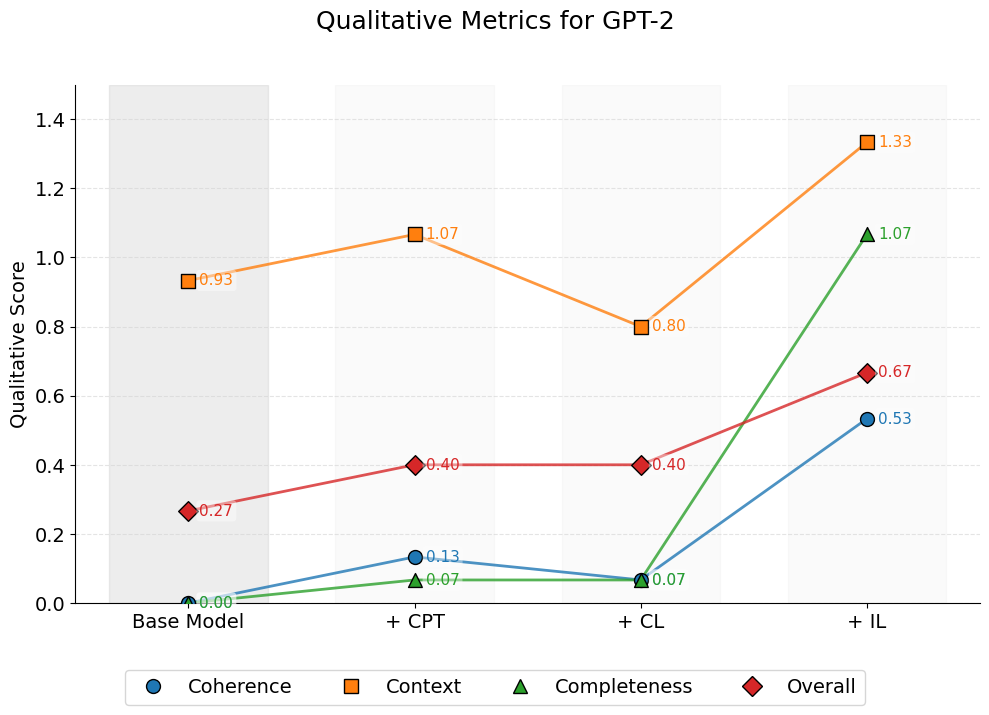

------------------------------
Processing: GPT-2 Large (Standard 4 stages)


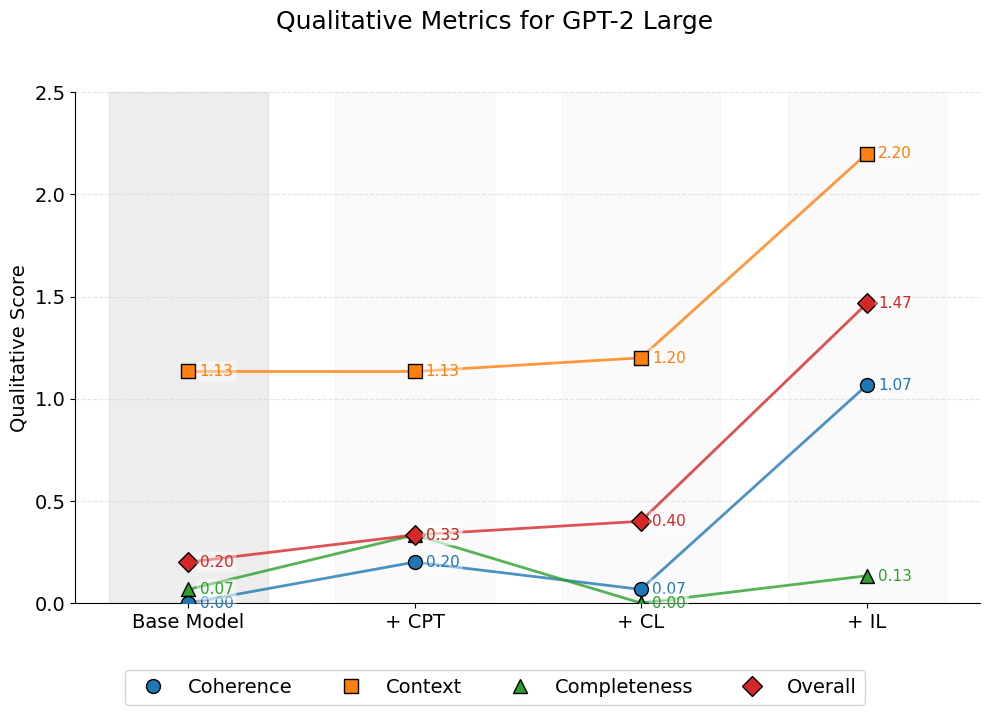

------------------------------
Processing: Mistral (Mistral 6 stages)


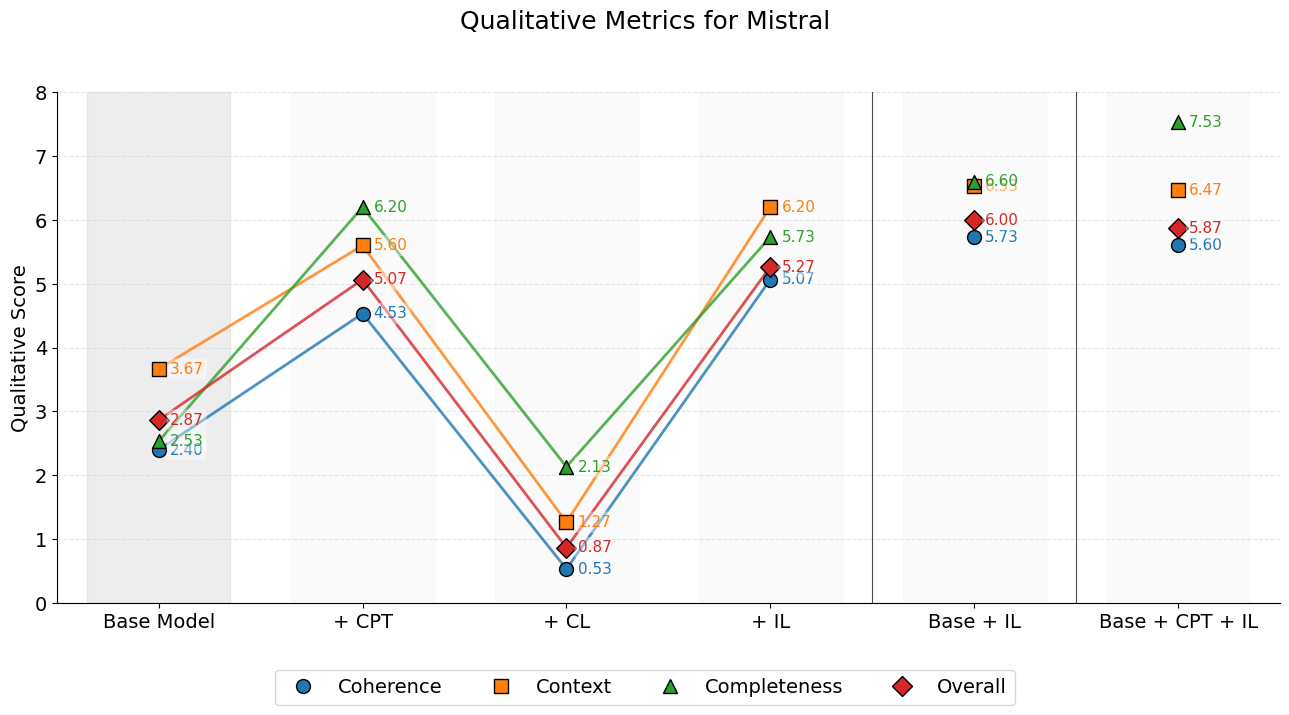

------------------------------
Finished processing all specified files.


In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import openpyxl # Required by pandas for reading xlsx
import os
import math # For checking NaN

# --- Configuration ---
# Files to process
# Hardcode path (Update this path if necessary)
# Example: base_path = '/path/to/your/data/folder/'
# If the script is in the same directory as the data folder's parent:
# base_path = os.path.join(os.path.dirname(__file__), 'data')
base_path = '/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/' # Example Path

files_to_process = [
    os.path.join(base_path, 'Qual_Performances_GPT2_small.xlsx'),
    os.path.join(base_path, 'Qual_Performances_GPT2_large.xlsx'),
    os.path.join(base_path, 'Qual_Performances_Mistral.xlsx') # Ensure this file exists
]

# Metrics to plot from the files
metrics_to_plot = ['Coherence', 'Context', 'Completeness', 'Overall']

# Define the standard order of training types for the x-axis FOR non-Mistral PLOTS
standard_training_order = ['Raw', 'Continuous Pre-Trained', 'Curriculum Learning', 'Instruction Finetuned']
# Define the extended order for Mistral, including the new types
mistral_training_order = ['Raw', 'Continuous Pre-Trained', 'Curriculum Learning', 'Instruction Finetuned', 'Only IL', 'CPT + IL']


# Define styles for each metric (consistent across plots)
metric_colors = {
    'Coherence': '#1f77b4',    # Blue
    'Context': '#ff7f0e',      # Orange
    'Completeness': '#2ca02c', # Green
    'Overall': '#d62728',      # Red
}

metric_markers = {
    'Coherence': 'o',    # Circle
    'Context': 's',      # Square
    'Completeness': '^', # Triangle
    'Overall': 'D',      # Diamond
}

# Define training type positions on x-axis
# Standard positions for non-Mistral (4 stages)
standard_training_positions = {training: i+1 for i, training in enumerate(standard_training_order)}
# Extended positions for Mistral (6 stages)
mistral_training_positions = {training: i+1 for i, training in enumerate(mistral_training_order)}

# Define a standard offset for labels (right of the point)
LABEL_OFFSET_X = 8
LABEL_OFFSET_Y = 0
LABEL_HA = 'left'
LABEL_VA = 'center'
LABEL_FONTSIZE = 11
LABEL_BBOX_ALPHA = 0.4

# --- Plotting Function ---
def plot_qualitative_metrics(filename, metrics, std_training_order, mst_training_order, std_training_positions, mst_training_positions, metric_colors, metric_markers):
    """
    Generates and displays a plot for qualitative metrics.
    Plots 4 stages for standard models, 6 stages for Mistral.
    For Mistral, lines only connect the first 4 stages. Stages 5 and 6 are plotted as points only.
    Adds vertical separators for the Mistral plot between stages 4&5 and 5&6.
    Labels are placed to the right of each data point.
    """
    is_mistral = "mistral" in filename.lower()
    model_key = 'Mistral' if is_mistral else 'Default' # Used for informational printing

    # Determine the training order and positions based on model type
    current_training_order = mst_training_order if is_mistral else std_training_order
    current_training_positions = mst_training_positions if is_mistral else std_training_positions
    num_stages = len(current_training_order)

    try:
        df_full = pd.read_excel(filename, engine='openpyxl')
        # Filter only the necessary rows for this specific model type
        df = df_full[df_full['TrainingType'].isin(current_training_order)].copy()
        if len(df) < num_stages:
            print(f"Warning: Missing some expected rows for {model_key} in {filename}. Expected {num_stages}, found {len(df)}.")
            print(f"Expected: {current_training_order}")
            print(f"Found: {df['TrainingType'].tolist()}")

    except FileNotFoundError:
        print(f"Error: File not found at {filename}")
        # Create dummy data if file not found
        model_name_dummy = os.path.basename(filename).split('.')[0].replace('Qual_Performances_', '')
        data = {
            'Model': [model_name_dummy] * num_stages,
            'TrainingType': current_training_order,
            'Correctness': [0] * num_stages,
            'Coherence': np.random.rand(num_stages) * 8 ,
            'Context': np.random.rand(num_stages) * 8 ,
            'Completeness': np.random.rand(num_stages) * 8,
            'Overall': np.random.rand(num_stages) * 8,
        }
        df = pd.DataFrame(data)
        print(f"Using dummy data for {filename}.")

    # --- Data Preparation ---
    active_metrics = []
    for col in metrics:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            active_metrics.append(col)
        else:
            print(f"Warning: Metric column '{col}' not found in {filename}. Skipping.")

    if not active_metrics:
        print(f"Error: No valid metric columns found for {filename}. Skipping plot.")
        return

    df['TrainingType'] = pd.Categorical(df['TrainingType'], categories=current_training_order, ordered=True)
    df = df.sort_values('TrainingType')

    # Extract Model Name
    if 'Model' in df.columns and not df['Model'].empty:
         unique_models = df['Model'].unique()
         model_name = unique_models[0] if len(unique_models) > 0 else 'Unknown Model'
         if model_name == os.path.basename(filename).split('.')[0].replace('Qual_Performances_', ''):
             model_name_from_file = os.path.basename(filename).split('_')[-1].split('.')[0]
             if 'mistral' in model_name_from_file.lower(): model_name = 'Mistral'
             elif 'gpt2' in model_name_from_file.lower(): model_name = f"GPT-2 {model_name_from_file.split('-')[-1]}"
             else: model_name = model_name_from_file
    else:
        model_name_from_file = os.path.basename(filename).split('_')[-1].split('.')[0]
        if 'mistral' in model_name_from_file.lower(): model_name = 'Mistral'
        elif 'gpt2' in model_name_from_file.lower(): model_name = f"GPT-2 {model_name_from_file.split('-')[-1]}"
        else: model_name = model_name_from_file
    print(f"Processing: {model_name} ({'Mistral 6 stages' if is_mistral else 'Standard 4 stages'})")


    # --- Create Plot ---
    fig_width = 13 if is_mistral else 10
    fig, ax = plt.subplots(figsize=(fig_width, 7))
    all_y_values = []

    # --- Plotting Background Shaded Areas ---
    bar_width = 0.7
    background_patches = []
    for i, training in enumerate(current_training_order):
        x_pos = current_training_positions[training]
        if i == 0:
            alpha_value = 0.2; bg_color = 'darkgrey'
        else:
            alpha_value = 0.1; bg_color = 'lightgray'
        rect = plt.Rectangle((x_pos - bar_width/2, -10), bar_width, 20,
                              color=bg_color, alpha=alpha_value, zorder=0)
        ax.add_patch(rect)
        background_patches.append(rect)

    # --- Plotting Data Lines and Points ---
    metric_data = {metric: {'x': [], 'y': []} for metric in active_metrics}

    # Collect data points
    for metric in active_metrics:
        for training in current_training_order:
            data_row = df[df['TrainingType'] == training]
            x_pos = current_training_positions[training]
            if not data_row.empty:
                result = data_row[metric].iloc[0]
                if pd.notna(result):
                    metric_data[metric]['x'].append(x_pos)
                    metric_data[metric]['y'].append(result)
                    all_y_values.append(result)
                else:
                    metric_data[metric]['x'].append(x_pos)
                    metric_data[metric]['y'].append(np.nan)
            else:
                metric_data[metric]['x'].append(x_pos)
                metric_data[metric]['y'].append(np.nan)

    # Determine Y-axis limits
    min_y = 0
    if all_y_values:
         max_y_data = max(all_y_values)
         max_y = math.ceil(max(max_y_data * 1.05, min_y + 0.5) * 2) / 2
    else:
         max_y = 8
    ax.set_ylim(min_y, max_y)

    # Adjust background patch height and y-position
    for patch in background_patches:
        patch.set_y(min_y)
        patch.set_height(max_y - min_y)

    # Plot lines, points, and labels for each metric
    for metric in active_metrics:
        data = metric_data[metric]
        x_values_full = data['x']
        y_values_full = data['y']
        if not x_values_full: continue

        # Determine Data for Line Plotting
        if is_mistral:
            mistral_line_limit_pos = std_training_positions['Instruction Finetuned']
            x_values_line = []
            y_values_line = []
            for i, x in enumerate(x_values_full):
                if x <= mistral_line_limit_pos:
                    x_values_line.append(x_values_full[i])
                    y_values_line.append(y_values_full[i])
        else:
            x_values_line = x_values_full
            y_values_line = y_values_full

        # Line Plotting (Using potentially truncated data)
        valid_segments_x, valid_segments_y = [], []
        current_segment_x, current_segment_y = [], []
        for i, y in enumerate(y_values_line):
            if pd.notna(y):
                current_segment_x.append(x_values_line[i])
                current_segment_y.append(y_values_line[i])
            else:
                if len(current_segment_x) > 1:
                    valid_segments_x.append(current_segment_x)
                    valid_segments_y.append(current_segment_y)
                current_segment_x, current_segment_y = [], []
        if len(current_segment_x) > 1:
             valid_segments_x.append(current_segment_x)
             valid_segments_y.append(current_segment_y)

        for seg_x, seg_y in zip(valid_segments_x, valid_segments_y):
             ax.plot(seg_x, seg_y, color=metric_colors[metric], linestyle='-',
                    linewidth=2, alpha=0.8, zorder=2)

        # Scatter Points (Plot ALL valid points using FULL data)
        valid_indices_full = [i for i, y in enumerate(y_values_full) if pd.notna(y)]
        ax.scatter([x_values_full[i] for i in valid_indices_full], [y_values_full[i] for i in valid_indices_full],
                  color=metric_colors[metric], marker=metric_markers[metric],
                  s=100, zorder=3, edgecolors='black', linewidth=1)

        # Labels (Add for ALL valid points using FULL data)
        for i in valid_indices_full:
            x = x_values_full[i]
            y = y_values_full[i]
            ax.annotate(
                f"{y:.2f}", xy=(x, y),
                xytext=(LABEL_OFFSET_X, LABEL_OFFSET_Y), textcoords='offset points',
                ha=LABEL_HA, va=LABEL_VA, fontsize=LABEL_FONTSIZE,
                color=metric_colors[metric],
                bbox=dict(boxstyle="round,pad=0.2", fc='white', ec="none", alpha=LABEL_BBOX_ALPHA),
                zorder=4
            )

    # --- Add Vertical Separator Lines for Mistral ---
    if is_mistral:
        # Separator between "+ IL" (pos 4) and "Base + IL" (pos 5)
        ax.axvline(x=4.5, color='black', linestyle='-', linewidth=0.8, alpha=0.7, zorder=1)
        # Separator between "Base + IL" (pos 5) and "Base + CPT + IL" (pos 6)
        ax.axvline(x=5.5, color='black', linestyle='-', linewidth=0.8, alpha=0.7, zorder=1)


    # --- Axis Configuration ---
    if is_mistral:
        modified_labels = ["Base Model", "+ CPT", "+ CL", "+ IL", "Base + IL", "Base + CPT + IL"]
    else:
        modified_labels = ["Base Model", "+ CPT", "+ CL", "+ IL"]

    ax.set_xticks(list(current_training_positions.values()))
    ax.set_xticklabels(modified_labels, fontsize=14, rotation=0, ha='center')
    ax.set_xlim(0.5, num_stages + 0.5)
    ax.set_ylabel('Qualitative Score', fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.6, color='lightgrey')
    ax.set_axisbelow(True)

    # --- Legend ---
    metric_legend = []
    for metric in metrics_to_plot:
        if metric in metric_colors and metric in metric_markers:
            metric_legend.append(Line2D([0], [0], marker=metric_markers[metric], color='w',
                                  label=metric, markersize=10, linestyle='None',
                                  markerfacecolor=metric_colors[metric], markeredgecolor='black'))

    fig.legend(handles=metric_legend, loc='upper center', bbox_to_anchor=(0.5, 0.06),
              ncol=len(metric_legend), fontsize=14)

    # --- Final Adjustments ---
    plt.suptitle(f"Qualitative Metrics for {model_name}", fontsize=18, y=0.99)
    plt.tight_layout(rect=[0, 0.08, 1, 0.96])

    # --- Show Plot ---
    plt.show()


# --- Main Execution ---
if __name__ == "__main__":
    if not os.path.isdir(base_path):
         print(f"Error: Base path '{base_path}' not found. Please update the 'base_path' variable.")
         files_to_process = []

    if not files_to_process:
        print("No valid files specified or base path incorrect. Exiting.")
    else:
        metrics_list = list(metrics_to_plot)
        for file_path in files_to_process:
            print("-" * 30)
            if not os.path.exists(file_path):
                print(f"Warning: File not found at {file_path}. Skipping.")
                continue

            plot_qualitative_metrics(
                filename=file_path,
                metrics=metrics_list,
                std_training_order=standard_training_order,
                mst_training_order=mistral_training_order,
                std_training_positions=standard_training_positions,
                mst_training_positions=mistral_training_positions,
                metric_colors=metric_colors,
                metric_markers=metric_markers
            )

        print("-" * 30)
        print("Finished processing all specified files.")

Plotting data from: /Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/Qual_Performances_Best.xlsx


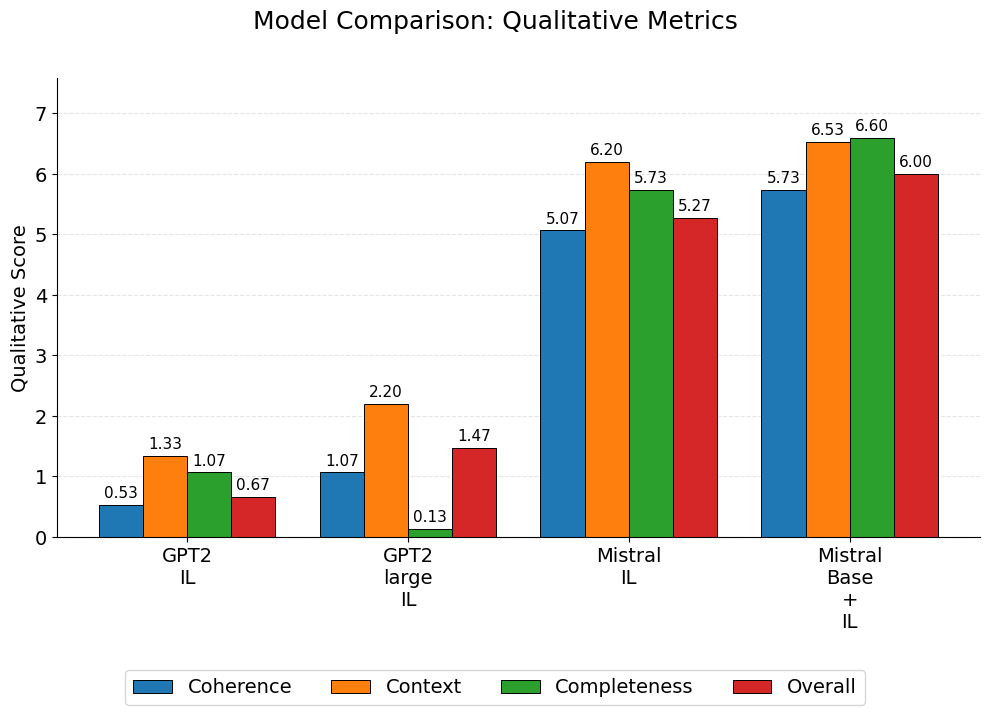

------------------------------
Finished processing.


In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import openpyxl # Required by pandas for reading xlsx
import os
import math # For checking NaN

# --- Configuration ---
# File path for the data
base_path = '/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/'
file_path = os.path.join(base_path, 'Qual_Performances_Best.xlsx')

# Metrics to plot from the file (these will be the clusters)
metrics_to_plot = ['Coherence', 'Context', 'Completeness', 'Overall']

# Define styles matching previous plots
metric_colors = {
    'Coherence': '#1f77b4',    # Blue
    'Context': '#ff7f0e',      # Orange
    'Completeness': '#2ca02c', # Green
    'Overall': '#d62728',      # Red
}

# Font sizes matching previous plots
TITLE_FONTSIZE = 18
AXIS_LABEL_FONTSIZE = 14
TICK_LABEL_FONTSIZE = 14
BAR_LABEL_FONTSIZE = 11
LEGEND_FONTSIZE = 14


# --- Plotting Function ---
def plot_clustered_bars(df, metrics, colors):
    """
    Generates a clustered bar chart for comparing models across specified metrics.
    """
    # Prepare data for plotting
    models = df.index.tolist()
    n_models = len(models)
    n_metrics = len(metrics)

    # Calculate bar positions
    bar_width = 0.8 / n_metrics # Adjust gap between bars within a cluster (lower number = wider gap)
    index = np.arange(n_models) # Base positions for each model group

    # --- Create Plot ---
    fig, ax = plt.subplots(figsize=(10, 7)) # Adjust figure size as needed

    max_y_value = 0 # To set ylim later

    # Plot bars for each metric
    for i, metric in enumerate(metrics):
        # Calculate the offset for the bars of this metric within each cluster
        offset = (i - (n_metrics - 1) / 2) * bar_width
        metric_values = df[metric].values # Get values for the current metric

        # Update max y value
        current_max = metric_values[~np.isnan(metric_values)].max() if not np.all(np.isnan(metric_values)) else 0
        max_y_value = max(max_y_value, current_max)

        # Plot bars
        rects = ax.bar(index + offset, metric_values, bar_width,
                       label=metric, color=colors.get(metric, 'gray'), # Use .get for safety
                       edgecolor='black', linewidth=0.7)

        # Add labels on top of bars
        ax.bar_label(rects, padding=3, fmt='%.2f', fontsize=BAR_LABEL_FONTSIZE, color='black')


    # --- Axis Configuration and Styling ---
    ax.set_ylabel('Qualitative Score', fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_xticks(index)
    # Allow model names to wrap if they are long
    ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=TICK_LABEL_FONTSIZE, rotation=0, ha='center')
    ax.tick_params(axis='y', labelsize=TICK_LABEL_FONTSIZE)

    # Set Y-limit slightly above the highest bar label
    ax.set_ylim(0, max_y_value * 1.15) # Add 15% padding at the top

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.6, color='lightgrey', zorder=0)
    ax.set_axisbelow(True) # Ensure grid is behind bars

    # --- Legend ---
    # Place legend below the plot
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.06),
              ncol=len(metrics), fontsize=LEGEND_FONTSIZE)

    # --- Title ---
    plt.suptitle("Model Comparison: Qualitative Metrics", fontsize=TITLE_FONTSIZE, y=0.99)

    # --- Final Adjustments ---
    plt.tight_layout(rect=[0, 0.08, 1, 0.97]) # Adjust rect for legend/title space

    # --- Show Plot ---
    plt.show()


# --- Main Execution ---
if __name__ == "__main__":
    # Check if base_path exists
    if not os.path.isdir(base_path):
         print(f"Error: Base path '{base_path}' not found. Please update the 'base_path' variable.")
    elif not os.path.exists(file_path):
        print(f"Error: File not found at {file_path}")
    else:
        try:
            # Read the Excel file, using the 'Model' column as the index
            df_data = pd.read_excel(file_path, engine='openpyxl', index_col='Model')

            # Ensure the required metric columns exist
            missing_metrics = [m for m in metrics_to_plot if m not in df_data.columns]
            if missing_metrics:
                print(f"Error: The following metric columns are missing in the file: {missing_metrics}")
            else:
                # Convert metric columns to numeric, coercing errors
                for metric in metrics_to_plot:
                    df_data[metric] = pd.to_numeric(df_data[metric], errors='coerce')

                # Filter only the required metrics for plotting
                df_plot = df_data[metrics_to_plot]

                # Call the plotting function
                print(f"Plotting data from: {file_path}")
                plot_clustered_bars(df_plot, metrics_to_plot, metric_colors)

        except Exception as e:
            print(f"An error occurred while processing the file: {e}")

        print("-" * 30)
        print("Finished processing.")